# Affichage des courbes de charge

Notebook unique du projet : il regroupe l'affichage brut, la semaine type et le talon
(puissance de base), qui etaient auparavant repartis dans plusieurs scripts separes
(`utils_energie.py`, `visu_brute.py`, `talon.py`).

Toutes les fonctions vivent desormais dans un seul fichier bibliotheque : **`utils_energie.py`**
(a garder dans le meme dossier que ce notebook).

In [38]:
# Pour eviter d'avoir a recharger le kernel a chaque modification de la bibliotheque
%load_ext autoreload
%autoreload 2

from fonctions import (
    charger,
    tracer,
    tracer_semaine_type_mois,
    tracer_semaine_type_mois_filtre,
    tracer_talon,
    tracer_talon_annuel_dynamique,
)

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Chargement des donnees

In [39]:
# Chemins des fichiers du projet
Argile   = "Courbes de charge Mines/Argile.xlsx"
Basalte  = "Courbes de charge Mines/Basalte.xlsx"
Charbon  = "Courbes de charge Mines/Charbon.xlsx"
Diamant  = "Courbes de charge Mines/Diamant.xlsx"
Emeraude = "Courbes de charge Mines/Emeraude.xlsx"
Filon    = "Courbes de charge Mines/Filon.xlsx"
Granite  = "Courbes de charge Mines/Granite.xlsx"
Houille  = "Courbes de charge Mines/Houille.xlsx"
Ivoire   = "Courbes de charge Mines/Ivoire.xlsx"
Jade     = "Courbes de charge Mines/Jade.xlsx"
Kiwi     = "Courbes de charge Mines/Kiwi.xlsx"
Lave     = "Courbes de charge Mines/Lave.xlsx"

dataset_name = Ivoire  # a modifier avec celui qu'on veut afficher

df = charger(dataset_name)

# Certains fichiers sont exprimes en kW plutot qu'en W -> on remet tout a la meme echelle
if dataset_name not in (Argile, Basalte, Charbon, Emeraude):
    df = df * 1000

# Affichage rapide pour verifier
display(df.head())
print(f"{dataset_name} : {df.index.min()} -> {df.index.max()}  ({len(df)} points)")

,kW
2024-06-01 00:00:00,1.89
2024-06-01 00:10:00,1.89
2024-06-01 00:20:00,1.86
2024-06-01 00:30:00,1.89
2024-06-01 00:40:00,1.89


Courbes de charge Mines/Ivoire.xlsx : 2024-06-01 00:00:00 -> 2026-06-01 23:50:00  (105252 points)


## 2. Courbe brute des données les plus récentes à différentes échelles

**Utilisation de `tracer` :** appeler `tracer(df, echelle="...", debut="...")` en modifiant le
parametre `echelle` (`"jour"`, `"semaine"`, `"mois"`, `"annee"`, `"tout"`) pour ajuster le zoom
temporel, et optionnellement `debut` (`"AAAA-MM-JJ"`) pour cibler une date precise.

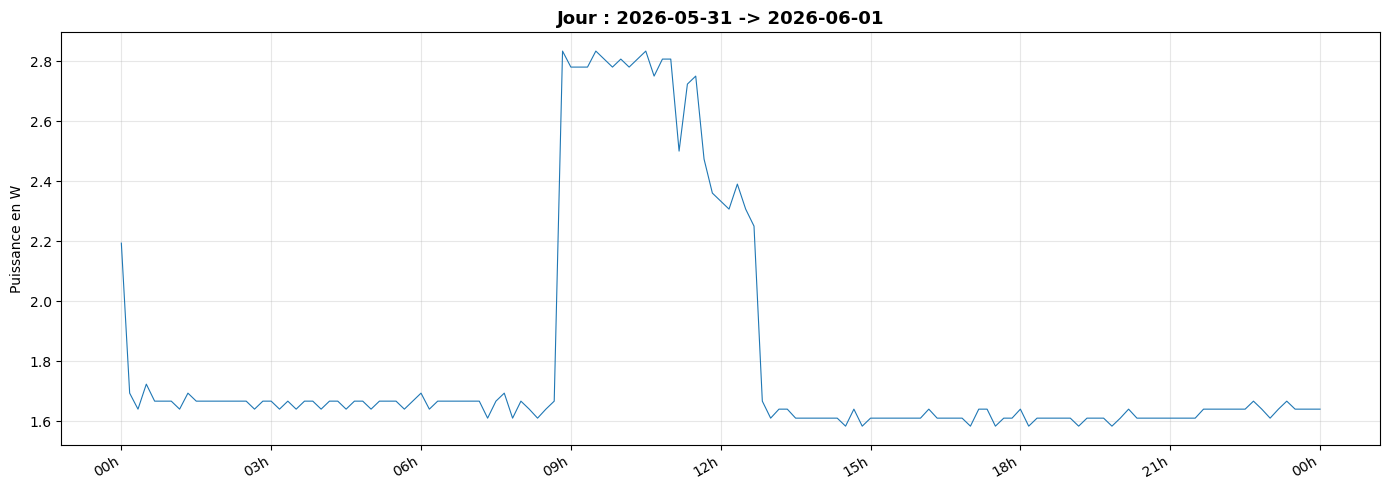

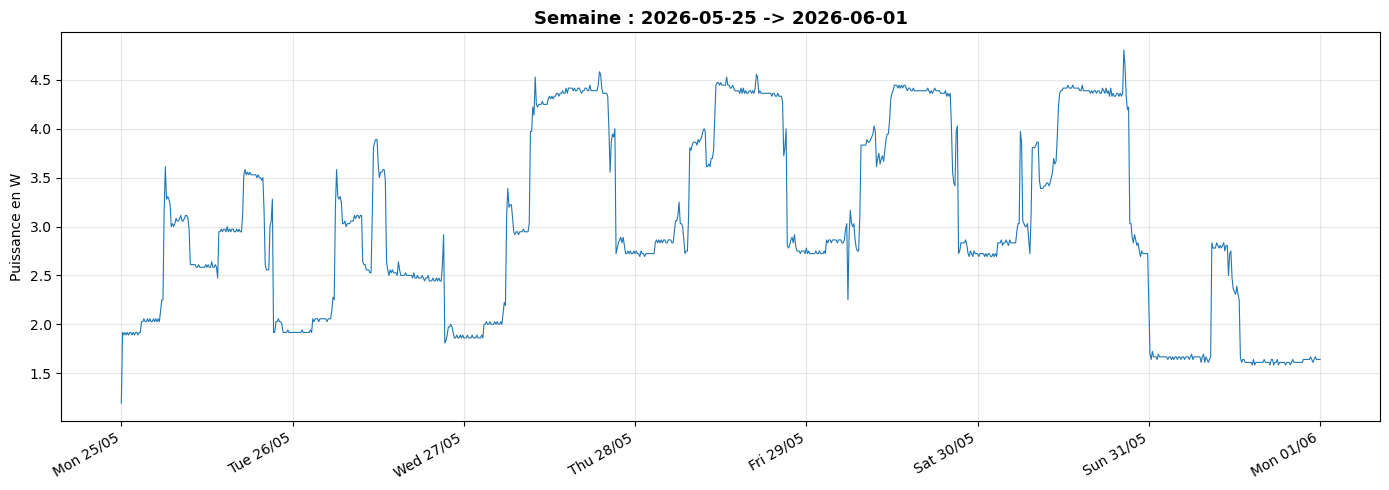

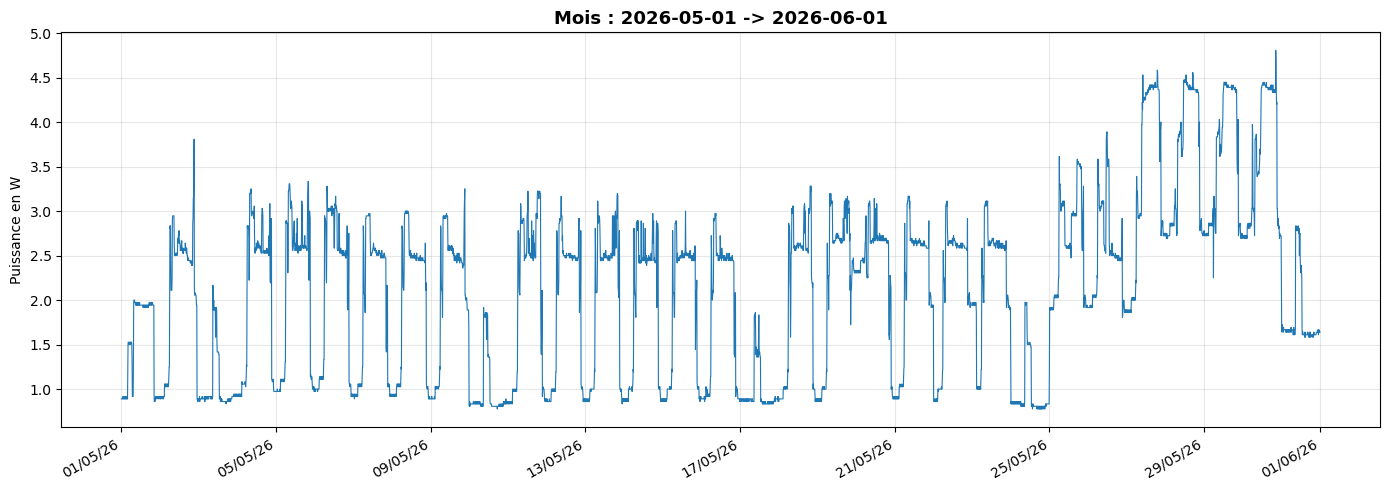

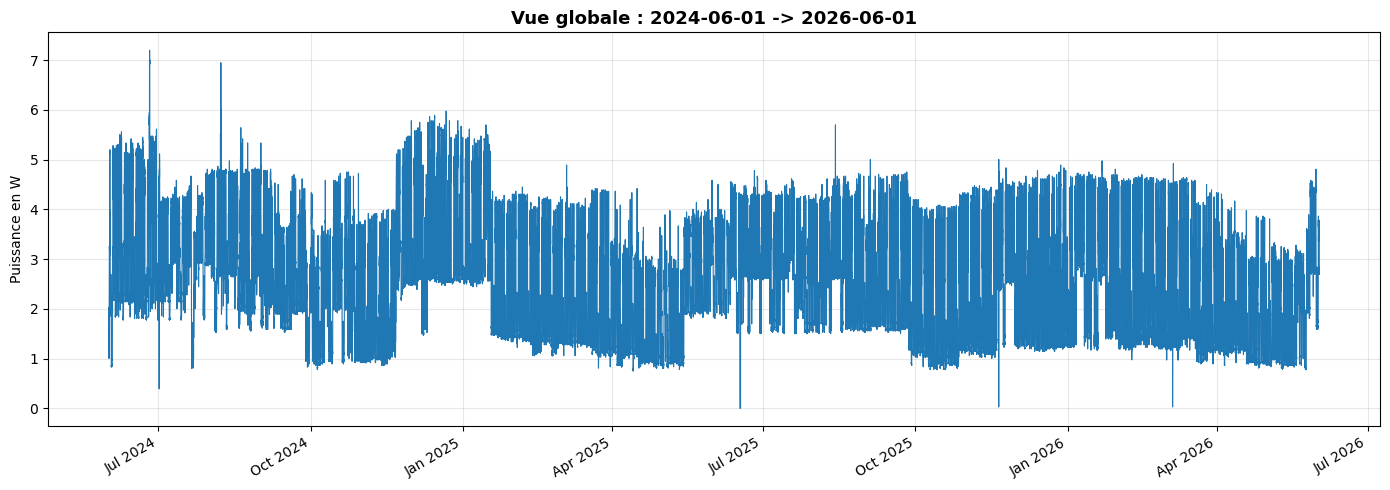

In [40]:
tracer(df, echelle="jour")
tracer(df, echelle="semaine")
tracer(df, echelle="mois")
tracer(df, echelle="tout")

## 3. Semaine type d'un mois

**Utilisation de `tracer_semaine_type_mois` :** appeler `tracer_semaine_type_mois(df, mois=5)`
pour generer le graphique de la consommation moyenne d'une semaine type pour le mois choisi, sur
les 12 derniers mois. Si les donnees sont trop bruitees, preferez
`tracer_semaine_type_mois_filtre(df, mois=5, span=7)`, qui applique un filtre passe-bas pour
lisser la courbe et faire ressortir la tendance de fond. Le parametre optionnel `span` permet
d'ajuster la force de ce lissage.

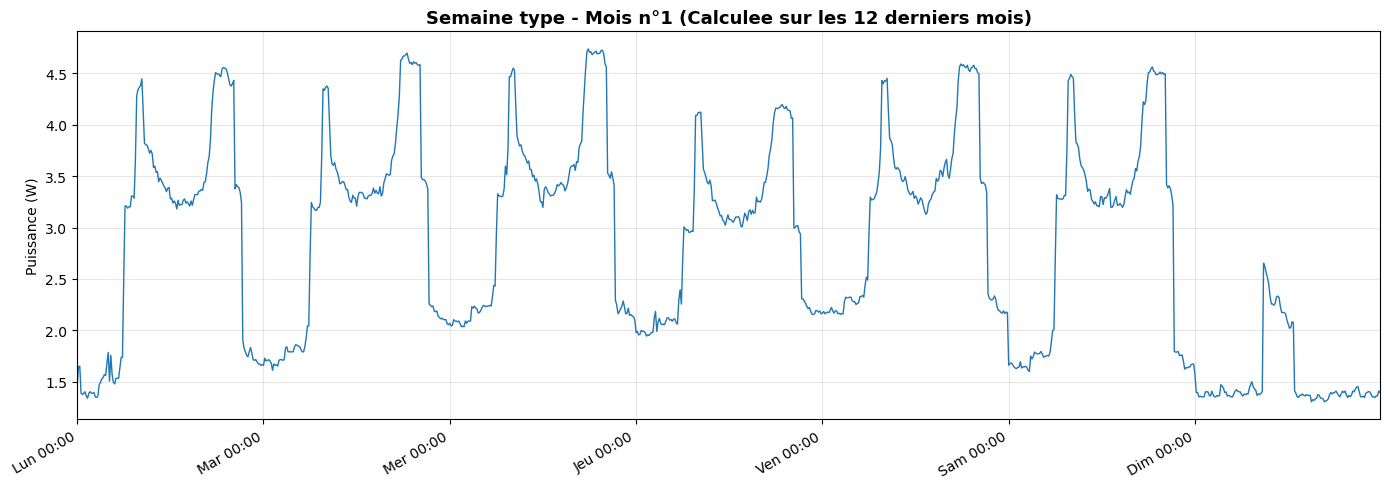

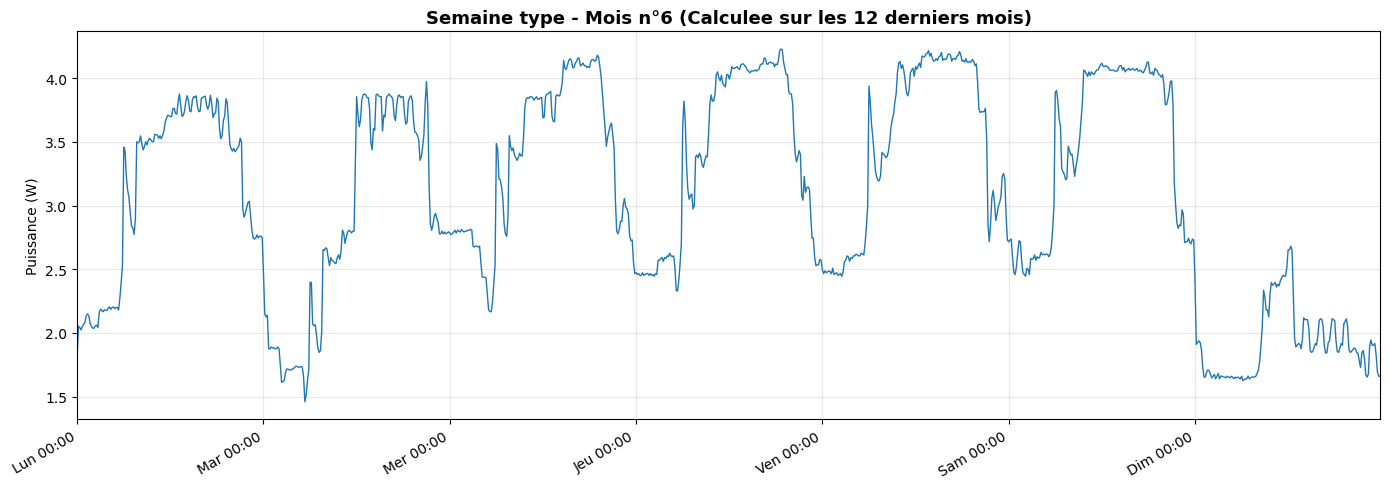

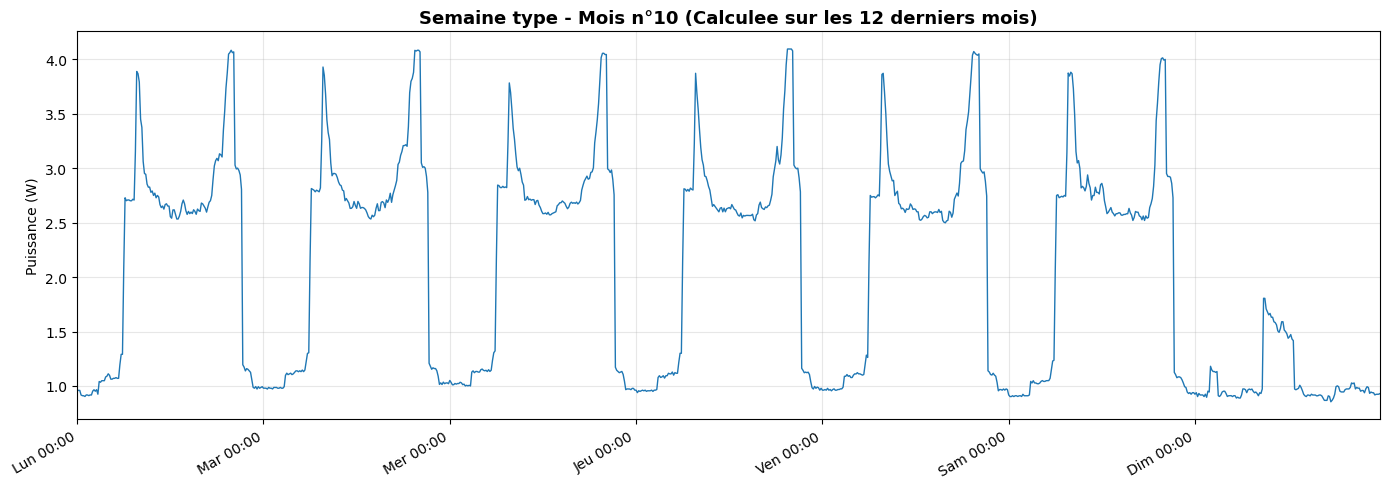

In [41]:
a = tracer_semaine_type_mois(df, mois=1)
b = tracer_semaine_type_mois(df, mois=6)
c = tracer_semaine_type_mois(df, mois=10)

## 4. Semaine type d'un mois lissée

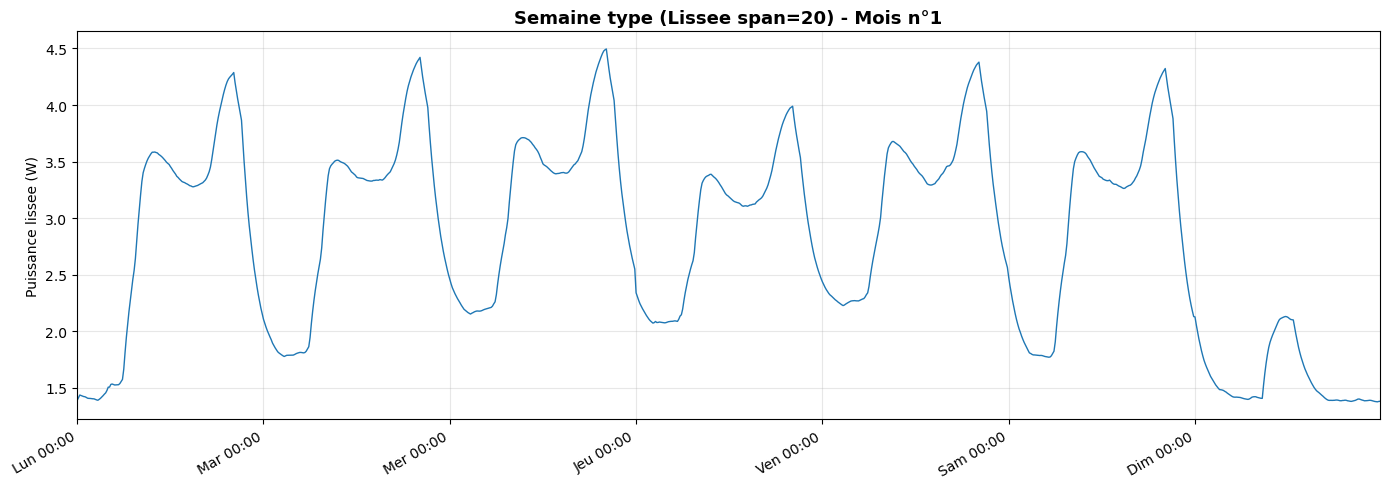

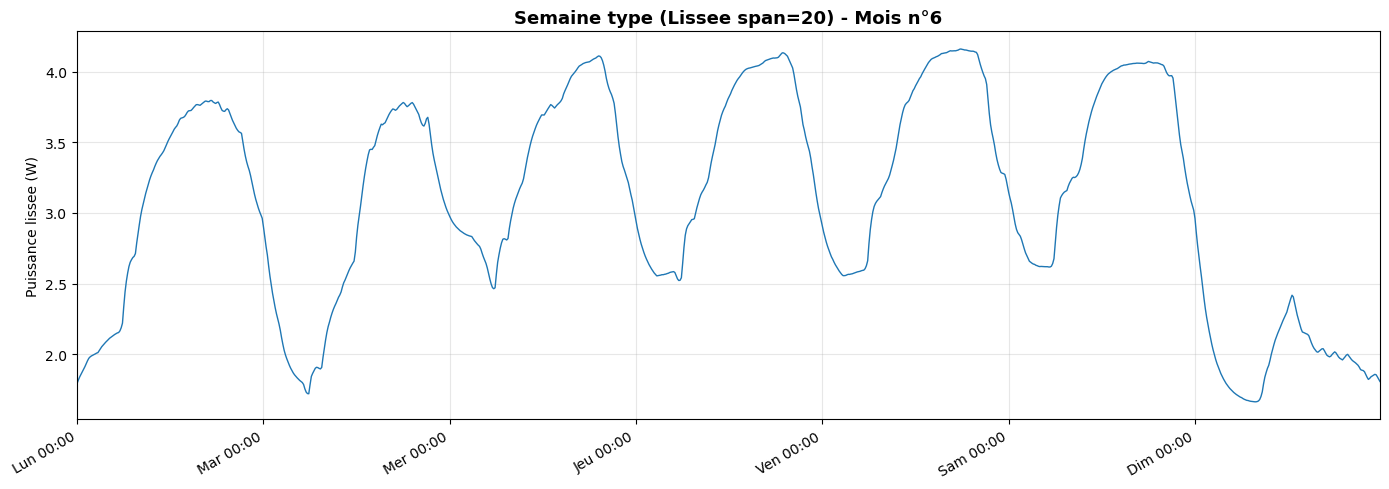

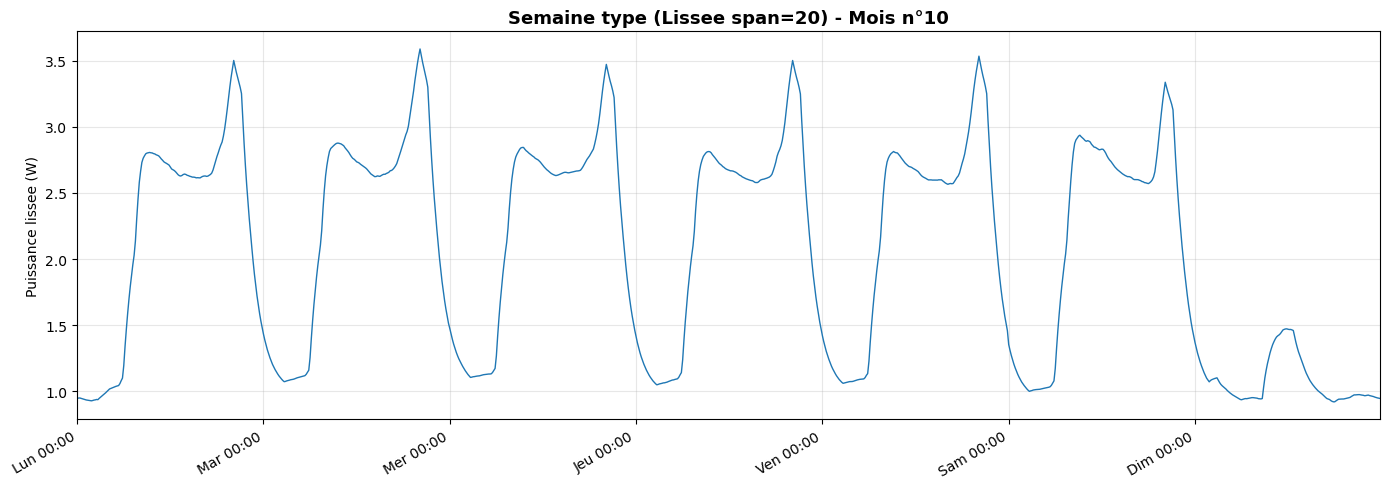

In [42]:
a = tracer_semaine_type_mois_filtre(df, span=20, mois=1)
b = tracer_semaine_type_mois_filtre(df, span=20, mois=6)
c = tracer_semaine_type_mois_filtre(df, span=20, mois=10)

## 4. Mise en évidence du talon

Méthode du percentile

- **`tracer_talon(chemin, debut=None, percentile=5, out=None)`** : talon sur une semaine
  (courbe + zone sous le talon + part d'energie sous le talon).
- **`tracer_talon_annuel_dynamique(chemin, fenetre_jours=30, percentile=5, out=None)`** : talon
  glissant sur l'annee entiere, pour voir son evolution au fil des mois.

Ces deux fonctions rechargent elles-memes le fichier a partir de son chemin (elles n'utilisent
pas le `df` charge plus haut).

Ivoire | semaine 2025-03-07 -> 2025-03-14
  talon (P5)         : 1.25
  part d'energie sous talon : 52 %


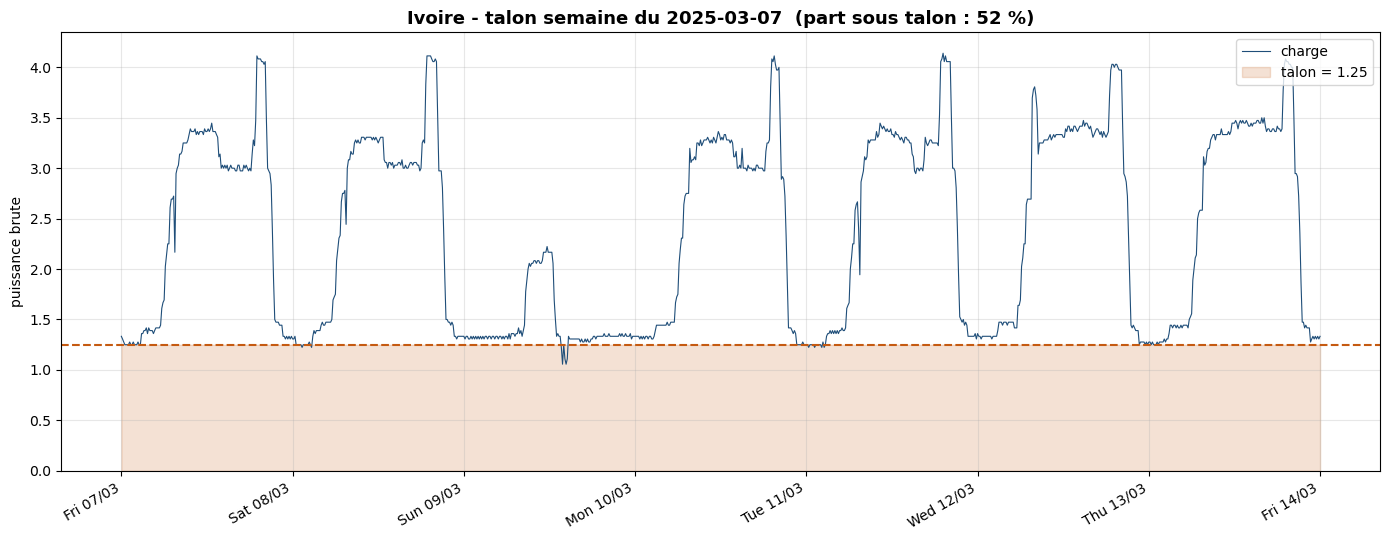

In [50]:
tracer_talon(df, echelle="semaine", debut="2025-03-07")

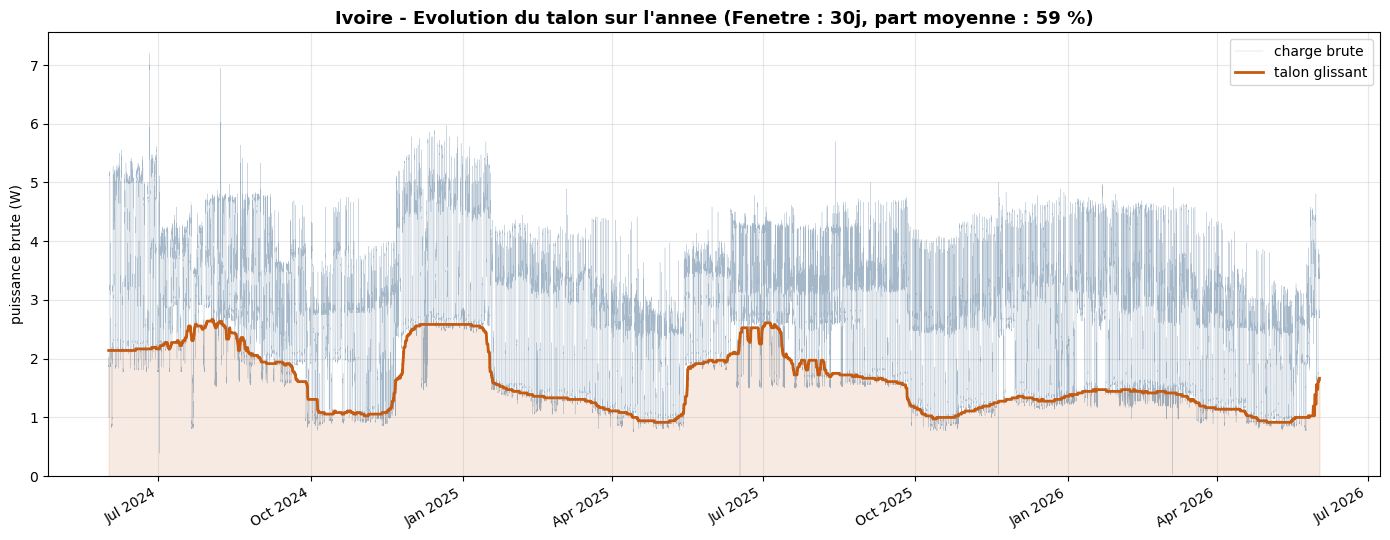

In [47]:
tracer_talon_annuel_dynamique(df, fenetre_jours=30, percentile=20)